In [2]:
import torch
import numpy as np
from PIL import Image
from datasets import load_dataset
from tqdm import tqdm
from transformers import LlavaOnevisionForConditionalGeneration, AutoProcessor

model_id = "llava-hf/llava-onevision-qwen2-7b-ov-hf"

model = LlavaOnevisionForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_id)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/765 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/621 [00:00<?, ?B/s]

In [3]:
from collections import Counter

# Load dataset
dataset = load_dataset("anvo25/vlms-are-biased", split="main")

def is_single_token(val):
    ids = processor.tokenizer.encode(str(val), add_special_tokens=False)
    return len(ids) == 1


# 1. Exclude optical illusions (watch spelling carefully)
dataset = dataset.filter(lambda x: x['topic'] != 'Optical Illusion')


# 2. Keep only single-token GT + bias
dataset = dataset.filter(
    lambda x: is_single_token(x['ground_truth']) and is_single_token(x['expected_bias'])
)


# 3. Sanity check distribution
topic_counts = Counter(dataset['topic'])
for topic, count in topic_counts.items():
    print(f"{topic}: {count}")

print(f"\nTotal: {len(dataset)}")

Filter:   0%|          | 0/2784 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1992 [00:00<?, ? examples/s]

Game Boards: 84
Patterned Grid: 336
Chess Pieces: 138
Logos: 414
Flags: 156
Animals: 546

Total: 1674


In [26]:
import re

def run_with_logprobs(image, prompt):
    # --- Proper chat format for LLaVA ---
    messages = [{
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": prompt}
        ]
    }]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        images=image,
        text=[text],
        return_tensors="pt"
    ).to("cuda")

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False,
            return_dict_in_generate=True,
            output_scores=True,
            pad_token_id=processor.tokenizer.eos_token_id
        )

    # --- Log probs ---
    scores = torch.stack(output.scores, dim=0).squeeze(1)
    log_probs = torch.log_softmax(scores, dim=-1)

    # --- Generated tokens only ---
    input_len = inputs["input_ids"].shape[1]
    gen_tokens = output.sequences[0][input_len:]

    response = processor.tokenizer.decode(gen_tokens, skip_special_tokens=True)

    return response, log_probs, output.sequences[0], inputs


def get_answer_token_id(text):
    ids = processor.tokenizer.encode(str(text), add_special_tokens=False)
    return ids[0] if len(ids) == 1 else None


def analyze_sample(sample):
    gt = str(sample['ground_truth'])
    bias = str(sample['expected_bias'])

    gt_token_id = get_answer_token_id(gt)
    bias_token_id = get_answer_token_id(bias)

    if gt_token_id is None or bias_token_id is None:
        return None

    answer, log_probs, tokens, inputs = run_with_logprobs(
        sample['image'],
        sample['prompt']
    )

    # --- Slice generated tokens ---
    input_len = inputs['input_ids'].shape[1]
    gen_tokens = tokens[input_len:]

   
    full_text = answer.lower()
    match = re.search(r"\d", full_text)

    # --- FIXED detection ---
    answer_step = None
    detected_digit = None

    generated_text = ""

    for i, tok_id in enumerate(gen_tokens):
        tok_str = processor.tokenizer.decode([tok_id])
        generated_text += tok_str

        match = re.search(r"\d", tok_str)
        if match:
            detected_digit = match.group()
            answer_step = i
            break

    margin, entropy = None, None

    if answer_step is not None:
        lp = log_probs[answer_step]

        margin = (lp[gt_token_id] - lp[bias_token_id]).item()
        entropy = -(lp.exp() * lp).sum().item()

    return {
        "topic": sample['topic'],
        "question_type": sample['type_of_question'],
        "ground_truth": gt,
        "expected_bias": bias,
        "model_answer": answer,
        "detected_digit": detected_digit,
        "answer_step": answer_step,
        "correct": str(detected_digit) == str(gt),
        "margin": margin,
        "entropy": entropy
    }

In [29]:
from tqdm import tqdm

def run_batch(dataset, max_samples=None):
    results = []

    data = dataset if max_samples is None else dataset.select(range(max_samples))

    for sample in tqdm(data):
        try:
            r = analyze_sample(sample)
            if r is not None:
                results.append(r)
        except Exception:
            continue

    return results


results = run_batch(dataset)
print(f"Collected {len(results)}")

100%|██████████████████████████████████████████████████████████████████████| 1674/1674 [40:31<00:00,  1.45s/it]

Collected 1674


In [30]:
import pandas as pd

df = pd.DataFrame(results)

df.to_parquet("llava_phase1.parquet", index=False)

In [31]:
df_clean = df.dropna(subset=["answer_step", "margin", "entropy"])

print("Usable samples:", len(df_clean))

Usable samples: 1674


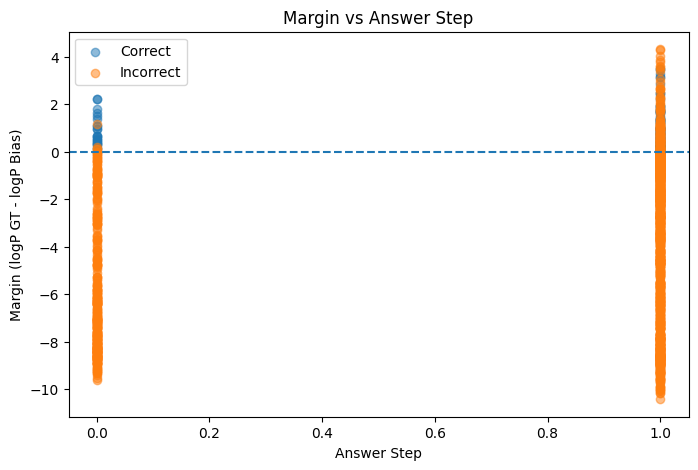

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for correct_val, label in [(True, "Correct"), (False, "Incorrect")]:
    subset = df_clean[df_clean["correct"] == correct_val]
    plt.scatter(subset["answer_step"], subset["margin"], alpha=0.5, label=label)

plt.axhline(0, linestyle="--")
plt.xlabel("Answer Step")
plt.ylabel("Margin (logP GT - logP Bias)")
plt.title("Margin vs Answer Step")
plt.legend()
plt.show()

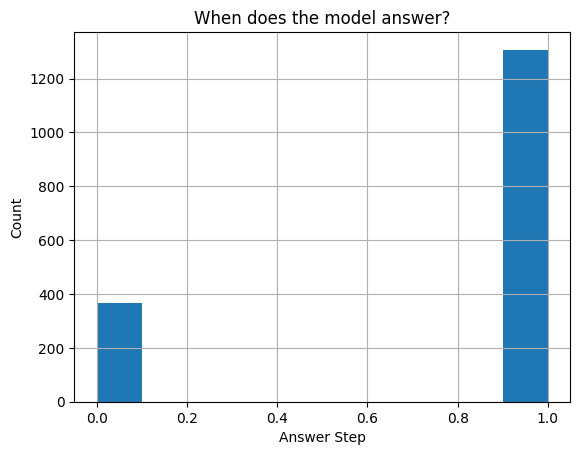

In [33]:
df_clean["answer_step"].hist(bins=10)

plt.xlabel("Answer Step")
plt.ylabel("Count")
plt.title("When does the model answer?")
plt.show()

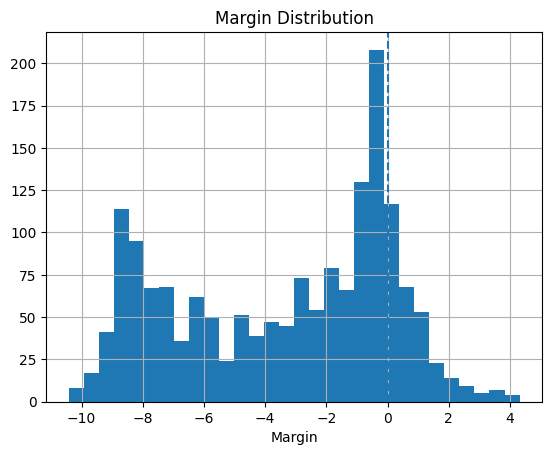

In [34]:
df_clean["margin"].hist(bins=30)

plt.axvline(0, linestyle="--")
plt.xlabel("Margin")
plt.title("Margin Distribution")
plt.show()

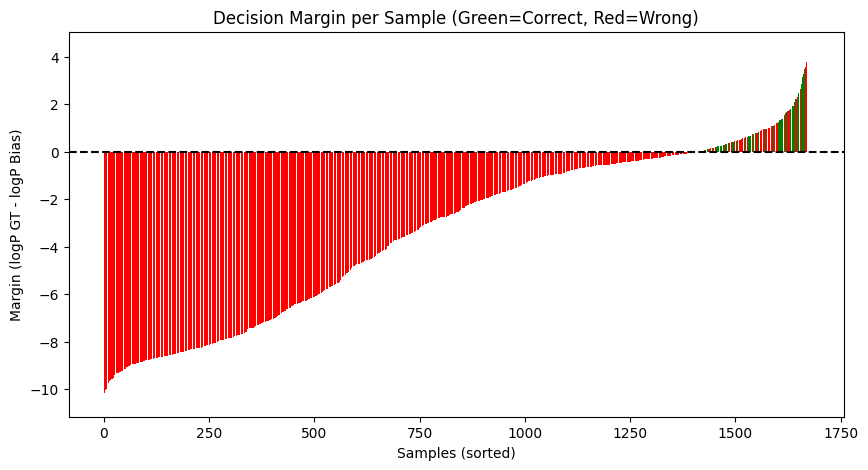

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

df_sorted = df_clean.sort_values("margin")

colors = df_sorted["correct"].map({True: "green", False: "red"})

plt.bar(range(len(df_sorted)), df_sorted["margin"], color=colors)

plt.axhline(0, linestyle="--", color="black")

plt.title("Decision Margin per Sample (Green=Correct, Red=Wrong)")
plt.ylabel("Margin (logP GT - logP Bias)")
plt.xlabel("Samples (sorted)")

plt.show()

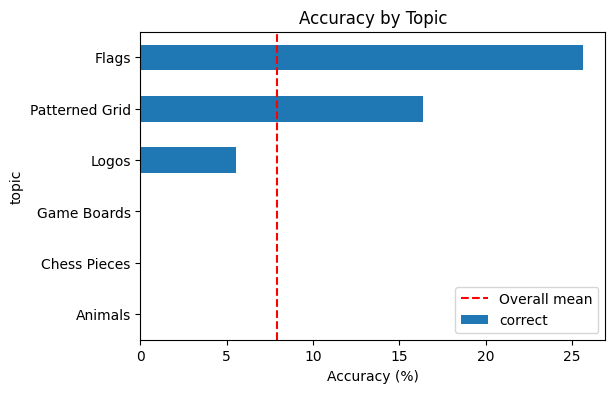

In [36]:
topic_acc = df.groupby("topic")["correct"].mean() * 100

plt.figure(figsize=(6,4))
topic_acc.sort_values().plot(kind="barh")

plt.axvline(topic_acc.mean(), color="red", linestyle="--", label="Overall mean")

plt.xlabel("Accuracy (%)")
plt.title("Accuracy by Topic")
plt.legend()

plt.show()

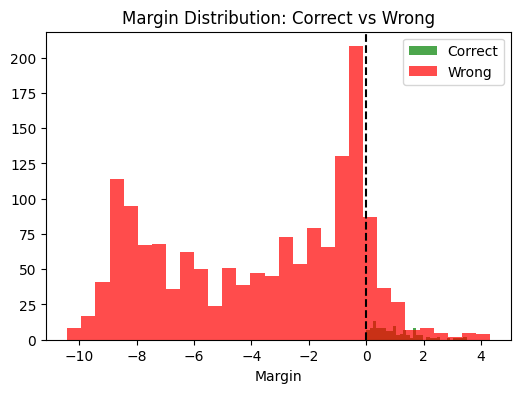

In [37]:
plt.figure(figsize=(6,4))

plt.hist(df_clean[df_clean["correct"]]["margin"], bins=30, alpha=0.7, label="Correct", color="green")
plt.hist(df_clean[~df_clean["correct"]]["margin"], bins=30, alpha=0.7, label="Wrong", color="red")

plt.axvline(0, linestyle="--", color="black")

plt.xlabel("Margin")
plt.title("Margin Distribution: Correct vs Wrong")
plt.legend()

plt.show()

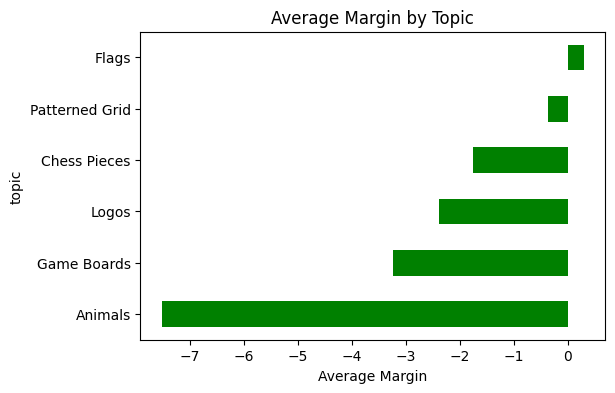

In [38]:
topic_margin = df_clean.groupby("topic")["margin"].mean().sort_values()

plt.figure(figsize=(6,4))
topic_margin.plot(kind="barh", color="green")

plt.xlabel("Average Margin")
plt.title("Average Margin by Topic")

plt.show()

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(df_clean[df_clean["correct"]]["entropy"], bins=30, alpha=0.7, label="Correct", color="green")
plt.hist(df_clean[~df_clean["correct"]]["entropy"], bins=30, alpha=0.7, label="Wrong", color="red")

plt.xlabel("Entropy")
plt.title("Entropy Distribution: Correct vs Wrong")
plt.legend()

plt.show()